# CNN Operations: From Scratch to Library Implementations

### Learning goals

This notebook demonstrates that I understand and can implement the core spatial operations used in Convolutional Neural Networks (CNNs):

- **2D Convolution**
- **Padding**
- **Stride**
- **Pooling** — Max Pooling and Average Pooling
- Manual implementations **from scratch using NumPy**
- Equivalent implementations using **TensorFlow / Keras**
- Visualizations of the input, kernels, intermediate outputs, and pooling windows
- Shape calculations and experiments with different padding and stride values

> **Learning approach:** First understand the mathematics and mechanics, then implement the operation manually, and finally compare it with a deep-learning library implementation.


## 1. Imports and visualization helpers

We use NumPy for the from-scratch implementations and TensorFlow/Keras for library-based implementations.
Matplotlib is used to visualize matrices, kernels, feature maps, and operation steps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

np.set_printoptions(precision=2, suppress=True)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1790066265.758589   16535 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790066265.865502   16535 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790066270.807200   16535 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## 2. A simple input image and convolution kernel

For learning, a small numerical matrix is easier to inspect than a real image.

The kernel slides over the input. At every position, the overlapping values are multiplied element-by-element with the kernel and summed.

For a 2D input $X$ and kernel $K$:

$$
Y(i,j)=\sum_m\sum_n X(i+m,j+n)K(m,n)
$$

In CNN terminology, this operation is usually called **convolution**, although deep-learning frameworks commonly implement the closely related **cross-correlation** operation (the kernel is not flipped). Our from-scratch implementation below follows the convention used by CNN libraries.

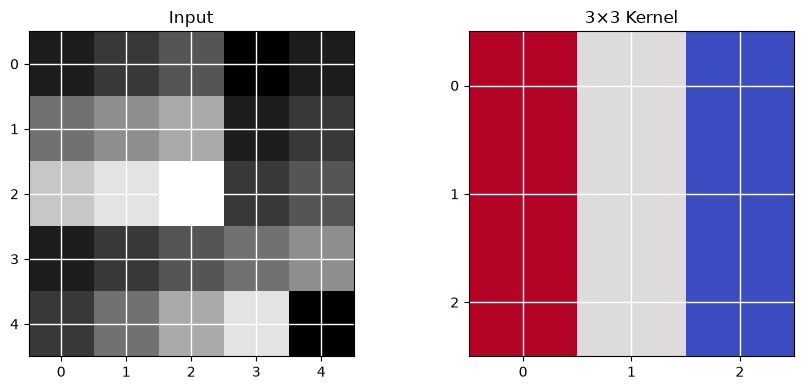

In [2]:
image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [1, 2, 3, 4, 5],
    [2, 4, 6, 8, 0]
], dtype=float)

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Input")
ax[1].imshow(kernel, cmap="coolwarm")
ax[1].set_title("3×3 Kernel")
for a in ax:
    a.set_xticks(range(a.images[0].get_array().shape[1]))
    a.set_yticks(range(a.images[0].get_array().shape[0]))
    a.grid(color="white", linewidth=1)
plt.tight_layout()
plt.show()


## 3. Output-size formula

For a 2D input of height $H$ and width $W$, kernel size $K$, padding $P$, and stride $S$:

$$
H_{out}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1
$$

$$
W_{out}=\left\lfloor\frac{W+2P-K}{S}\right\rfloor+1
$$

This formula is useful for predicting the feature-map size before performing the operation.

In [3]:
def conv_output_shape(input_shape, kernel_size, padding=0, stride=1):
    h, w = input_shape
    kh, kw = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
    out_h = (h + 2 * padding - kh) // stride + 1
    out_w = (w + 2 * padding - kw) // stride + 1
    return out_h, out_w

print("Input shape:", image.shape)
print("Valid, stride=1:", conv_output_shape(image.shape, kernel.shape, padding=0, stride=1))
print("Padding=1, stride=1:", conv_output_shape(image.shape, kernel.shape, padding=1, stride=1))
print("Padding=1, stride=2:", conv_output_shape(image.shape, kernel.shape, padding=1, stride=2))


Input shape: (5, 5)
Valid, stride=1: (3, 3)
Padding=1, stride=1: (5, 5)
Padding=1, stride=2: (3, 3)


# 4. Convolution from scratch

The algorithm is:

1. Pad the input if required.
2. Move the kernel according to the stride.
3. Extract the local window.
4. Multiply the window and kernel element-by-element.
5. Sum the products.
6. Store the result in the output feature map.

No convolution layer is used here — only NumPy.

In [4]:
def conv2d_from_scratch(x, kernel, padding=0, stride=1):
    x = np.asarray(x, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if x.ndim != 2 or kernel.ndim != 2:
        raise ValueError("This learning implementation expects 2D arrays.")

    if padding > 0:
        x = np.pad(x, ((padding, padding), (padding, padding)), mode="constant")

    kh, kw = kernel.shape
    out_h = (x.shape[0] - kh) // stride + 1
    out_w = (x.shape[1] - kw) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            row = i * stride
            col = j * stride
            window = x[row:row+kh, col:col+kw]
            output[i, j] = np.sum(window * kernel)

    return output

conv_valid = conv2d_from_scratch(image, kernel)
conv_same = conv2d_from_scratch(image, kernel, padding=1)
conv_stride2 = conv2d_from_scratch(image, kernel, padding=1, stride=2)

print("Valid convolution:\n", conv_valid)
print("\nPadding=1, stride=1:\n", conv_same)
print("\nPadding=1, stride=2:\n", conv_stride2)


Valid convolution:
 [[-6. 12. 12.]
 [-6.  8.  8.]
 [-8.  0. 10.]]

Padding=1, stride=1:
 [[ -7.  -4.   6.   6.   1.]
 [-15.  -6.  12.  12.   3.]
 [-15.  -6.   8.   8.   7.]
 [-14.  -8.   0.  10.  14.]
 [ -6.  -6.  -6.   4.  12.]]

Padding=1, stride=2:
 [[ -7.   6.   1.]
 [-15.   8.   7.]
 [ -6.  -6.  12.]]


## 5. Visualizing the convolution operation

The following visualization shows the kernel window moving across the input. This makes the relationship between **kernel size, stride, local receptive field, and output feature map** visible.

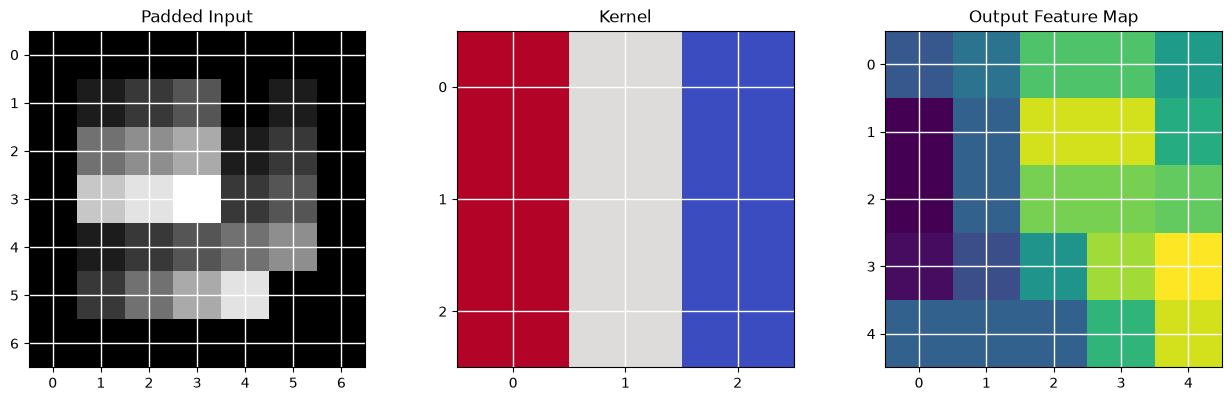

First convolution calculations:
Output[0,0] = sum(window * kernel) = -7.00
Output[0,1] = sum(window * kernel) = -4.00
Output[0,2] = sum(window * kernel) = 6.00
Output[0,3] = sum(window * kernel) = 6.00


In [5]:
def visualize_convolution_steps(x, kernel, padding=0, stride=1):
    x = np.asarray(x, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    padded = np.pad(x, ((padding, padding), (padding, padding)), mode="constant")
    kh, kw = kernel.shape
    oh = (padded.shape[0] - kh) // stride + 1
    ow = (padded.shape[1] - kw) // stride + 1
    output = conv2d_from_scratch(x, kernel, padding, stride)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(padded, cmap="gray", vmin=padded.min(), vmax=padded.max())
    axes[0].set_title("Padded Input")

    axes[1].imshow(kernel, cmap="coolwarm")
    axes[1].set_title("Kernel")

    axes[2].imshow(output, cmap="viridis")
    axes[2].set_title("Output Feature Map")

    for ax in axes:
        ax.set_xticks(range(ax.images[0].get_array().shape[1]))
        ax.set_yticks(range(ax.images[0].get_array().shape[0]))
        ax.grid(color="white", linewidth=1)

    plt.tight_layout()
    plt.show()

    # Show the first few actual windows
    print("First convolution calculations:")
    shown = 0
    for i in range(oh):
        for j in range(ow):
            r, c = i * stride, j * stride
            window = padded[r:r+kh, c:c+kw]
            value = np.sum(window * kernel)
            print(f"Output[{i},{j}] = sum(window * kernel) = {value:.2f}")
            shown += 1
            if shown == 4:
                return

visualize_convolution_steps(image, kernel, padding=1, stride=1)


# 6. Padding

**Padding** adds extra pixels around the boundary of an input.

Common reasons:

- Preserve spatial dimensions (**same-style convolution**).
- Allow border pixels to participate in more convolution windows.
- Control the output spatial size.

With zero padding, the added border values are zero.

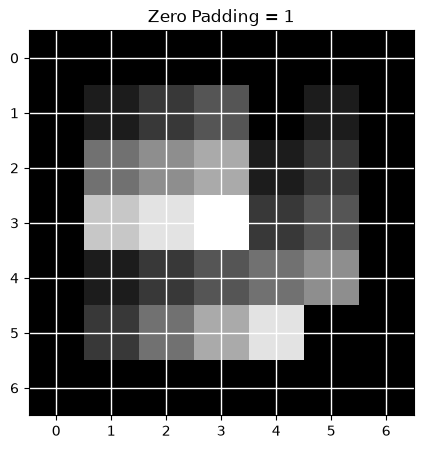

Original shape: (5, 5)
Padded shape: (7, 7)


In [6]:
def show_padding(x, padding):
    padded = np.pad(x, ((padding, padding), (padding, padding)), mode="constant")
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(padded, cmap="gray")
    ax.set_title(f"Zero Padding = {padding}")
    ax.set_xticks(range(padded.shape[1]))
    ax.set_yticks(range(padded.shape[0]))
    ax.grid(color="white", linewidth=1)
    plt.show()
    return padded

padded_image = show_padding(image, padding=1)
print("Original shape:", image.shape)
print("Padded shape:", padded_image.shape)


### Padding experiment

For a $5\times5$ input and a $3\times3$ kernel:

- No padding, stride 1 → $3\times3$
- Padding 1, stride 1 → $5\times5$

This demonstrates why padding is used when we want to retain spatial resolution.

In [7]:
for p in [0, 1, 2]:
    print(f"padding={p} -> output shape:",
          conv_output_shape(image.shape, kernel.shape, padding=p, stride=1))


padding=0 -> output shape: (3, 3)
padding=1 -> output shape: (5, 5)
padding=2 -> output shape: (7, 7)


# 7. Stride

**Stride** is the number of pixels by which the kernel moves after each operation.

- `stride = 1`: inspect every neighboring location.
- `stride = 2`: move two pixels at a time.
- Larger stride → smaller output feature map.

Thus stride can act as a form of **downsampling**.

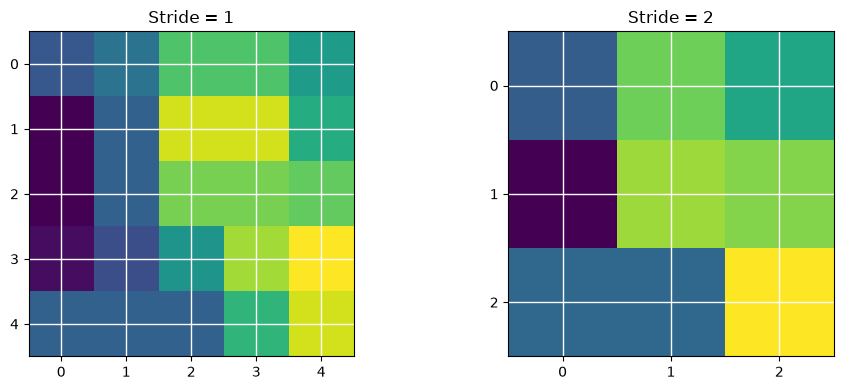

Stride 1 output shape: (5, 5)
Stride 2 output shape: (3, 3)


In [8]:
conv_s1 = conv2d_from_scratch(image, kernel, padding=1, stride=1)
conv_s2 = conv2d_from_scratch(image, kernel, padding=1, stride=2)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(conv_s1, cmap="viridis")
ax[0].set_title("Stride = 1")
ax[1].imshow(conv_s2, cmap="viridis")
ax[1].set_title("Stride = 2")
for a in ax:
    a.set_xticks(range(a.images[0].get_array().shape[1]))
    a.set_yticks(range(a.images[0].get_array().shape[0]))
    a.grid(color="white", linewidth=1)
plt.tight_layout()
plt.show()

print("Stride 1 output shape:", conv_s1.shape)
print("Stride 2 output shape:", conv_s2.shape)


# 8. Pooling from scratch

Pooling summarizes values inside a local window.

### Max Pooling
Takes the largest value:

$$
Y(i,j)=\max(X_{window})
$$

### Average Pooling
Takes the mean:

$$
Y(i,j)=\frac{1}{K^2}\sum X_{window}
$$

Pooling is commonly used to reduce spatial dimensions and summarize local features.

In [9]:
def pool2d_from_scratch(x, pool_size=2, stride=2, mode="max"):
    x = np.asarray(x, dtype=float)

    if isinstance(pool_size, int):
        ph = pw = pool_size
    else:
        ph, pw = pool_size

    out_h = (x.shape[0] - ph) // stride + 1
    out_w = (x.shape[1] - pw) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            r, c = i * stride, j * stride
            window = x[r:r+ph, c:c+pw]

            if mode == "max":
                output[i, j] = np.max(window)
            elif mode == "average":
                output[i, j] = np.mean(window)
            else:
                raise ValueError("mode must be 'max' or 'average'")

    return output

pool_input = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 3],
    [4, 1, 9, 5]
], dtype=float)

max_pool = pool2d_from_scratch(pool_input, pool_size=2, stride=2, mode="max")
avg_pool = pool2d_from_scratch(pool_input, pool_size=2, stride=2, mode="average")

print("Input:\n", pool_input)
print("\nMax Pooling:\n", max_pool)
print("\nAverage Pooling:\n", avg_pool)


Input:
 [[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [7. 2. 8. 3.]
 [4. 1. 9. 5.]]

Max Pooling:
 [[6. 4.]
 [7. 9.]]

Average Pooling:
 [[3.75 2.25]
 [3.5  6.25]]


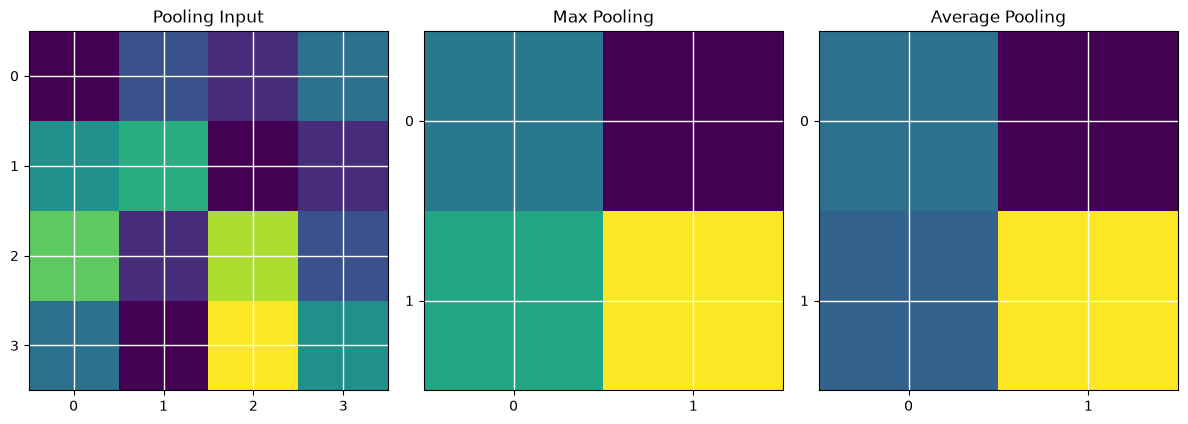

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, data, title in zip(
    ax,
    [pool_input, max_pool, avg_pool],
    ["Pooling Input", "Max Pooling", "Average Pooling"]
):
    a.imshow(data, cmap="viridis")
    a.set_title(title)
    a.set_xticks(range(data.shape[1]))
    a.set_yticks(range(data.shape[0]))
    a.grid(color="white", linewidth=1)

plt.tight_layout()
plt.show()


# 9. Library implementation with TensorFlow / Keras

Now we reproduce the same ideas using standard deep-learning layers.

- `tf.keras.layers.Conv2D`
- `tf.keras.layers.MaxPooling2D`
- `tf.keras.layers.AveragePooling2D`

For a fair comparison, we explicitly choose the kernel weights instead of letting Keras randomly initialize them.

In [11]:
# Keras Conv2D uses input shape: (batch, height, width, channels)
x_tf = image[np.newaxis, ..., np.newaxis].astype(np.float32)
k_tf = kernel[..., np.newaxis, np.newaxis].astype(np.float32)

conv_layer = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="valid",
    use_bias=False
)

_ = conv_layer(x_tf)
conv_layer.set_weights([k_tf])

keras_conv = conv_layer(x_tf).numpy()[0, :, :, 0]

print("From scratch:\n", conv_valid)
print("\nKeras Conv2D:\n", keras_conv)
print("\nMaximum absolute difference:",
      np.max(np.abs(conv_valid - keras_conv)))


E0000 00:00:1790066275.160369   16535 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


From scratch:
 [[-6. 12. 12.]
 [-6.  8.  8.]
 [-8.  0. 10.]]

Keras Conv2D:
 [[-6. 12. 12.]
 [-6.  8.  8.]
 [-8.  0. 10.]]

Maximum absolute difference: 0.0


In [12]:
# Keras convolution with padding='same' and stride=2
conv_layer_s2 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    use_bias=False
)

_ = conv_layer_s2(x_tf)
conv_layer_s2.set_weights([k_tf])

keras_conv_s2 = conv_layer_s2(x_tf).numpy()[0, :, :, 0]
scratch_conv_s2 = conv2d_from_scratch(image, kernel, padding=1, stride=2)

print("From scratch (explicit padding=1):\n", scratch_conv_s2)
print("\nKeras padding='same', stride=2:\n", keras_conv_s2)
print("\nMaximum absolute difference:",
      np.max(np.abs(scratch_conv_s2 - keras_conv_s2)))


From scratch (explicit padding=1):
 [[ -7.   6.   1.]
 [-15.   8.   7.]
 [ -6.  -6.  12.]]

Keras padding='same', stride=2:
 [[ -7.   6.   1.]
 [-15.   8.   7.]
 [ -6.  -6.  12.]]

Maximum absolute difference: 0.0


In [13]:
# Keras pooling
pool_x = pool_input[np.newaxis, ..., np.newaxis].astype(np.float32)

keras_max = tf.keras.layers.MaxPooling2D(pool_size=2, strides=2, padding="valid")
keras_avg = tf.keras.layers.AveragePooling2D(pool_size=2, strides=2, padding="valid")

max_keras = keras_max(pool_x).numpy()[0, :, :, 0]
avg_keras = keras_avg(pool_x).numpy()[0, :, :, 0]

print("Max pooling matches:",
      np.allclose(max_pool, max_keras))
print("Average pooling matches:",
      np.allclose(avg_pool, avg_keras))


Max pooling matches: True
Average pooling matches: True


# 10. A reusable visualization utility

The next function lets us visually compare the input, kernel, convolution output, and pooling output for different settings.

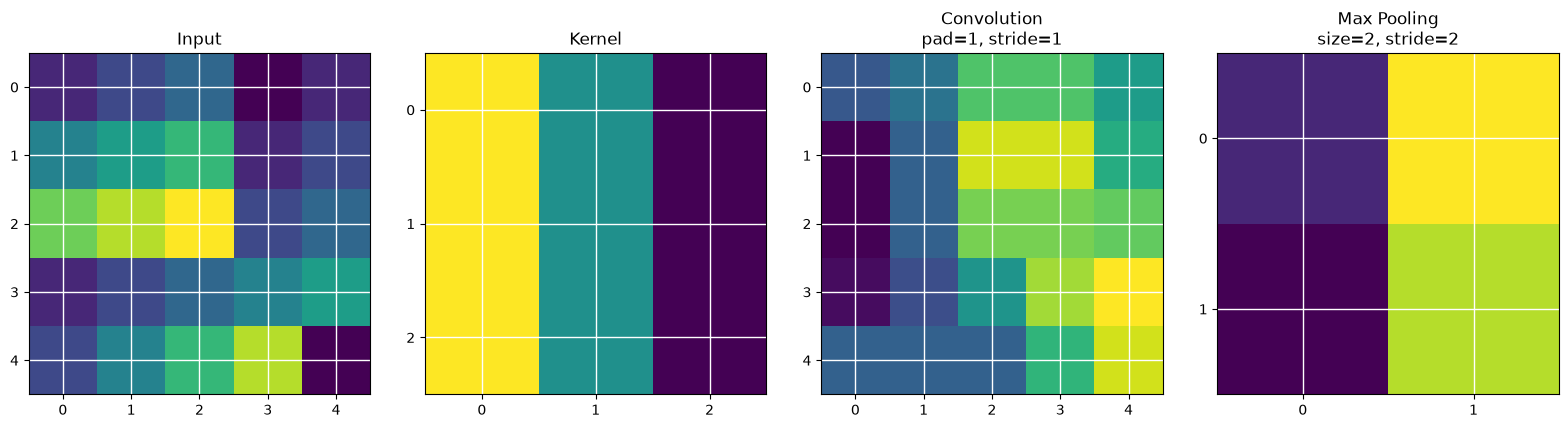

In [14]:
def visualize_cnn_operations(x, kernel, padding=0, stride=1, pool_size=2):
    conv = conv2d_from_scratch(x, kernel, padding=padding, stride=stride)
    pooled = pool2d_from_scratch(conv, pool_size=pool_size, stride=pool_size, mode="max")

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    items = [
        (x, "Input"),
        (kernel, "Kernel"),
        (conv, f"Convolution\npad={padding}, stride={stride}"),
        (pooled, f"Max Pooling\nsize={pool_size}, stride={pool_size}")
    ]

    for a, (data, title) in zip(ax, items):
        a.imshow(data, cmap="viridis")
        a.set_title(title)
        a.set_xticks(range(data.shape[1]))
        a.set_yticks(range(data.shape[0]))
        a.grid(color="white", linewidth=1)

    plt.tight_layout()
    plt.show()

visualize_cnn_operations(image, kernel, padding=1, stride=1, pool_size=2)


# 11. Mini end-to-end CNN example

A CNN repeatedly applies learned filters to extract spatial patterns and may then use pooling to reduce spatial resolution.

A simple conceptual pipeline is:

**Input → Convolution → Activation → Pooling → Convolution → Pooling → Dense / Output**

Here we build a small Keras model to connect the individual operations to an actual CNN architecture.

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(8, kernel_size=3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
    tf.keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,098 (35.54 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

# 12. Experiments to demonstrate understanding

Try changing these values and observe the output shape and visualization:

1. Kernel size: `3×3` → `5×5`
2. Padding: `0`, `1`, `2`
3. Stride: `1` → `2`
4. Pool size: `2` → `3`
5. Pooling stride: `1` → `2`

### Suggested exercises

- Create a vertical-edge detector and a horizontal-edge detector.
- Apply the kernels to a custom binary image.
- Compare max pooling and average pooling on the same feature map.
- Verify the output-size formula against your actual NumPy outputs.
- Add a bias term to the from-scratch convolution.
- Extend the implementation from one channel to multiple input channels.
- Extend it to multiple filters/output channels.
- Compare a manually implemented multi-channel convolution against Keras `Conv2D`.


# 13. Key takeaways

| Concept | What it does | Main effect |
|---|---|---|
| **Convolution** | Applies a local kernel/filter | Extracts spatial features |
| **Kernel / Filter** | Learnable pattern detector | Detects edges, textures, shapes, etc. |
| **Padding** | Adds border values | Controls border information and output size |
| **Stride** | Controls kernel movement | Larger stride reduces spatial resolution |
| **Max Pooling** | Selects maximum local value | Keeps strongest local activation |
| **Average Pooling** | Computes local average | Produces a smoothed summary |
| **Keras layers** | Provides optimized implementations | Practical CNN construction |

### What this notebook demonstrates

- Mathematical understanding of CNN spatial operations.
- Manual implementation using NumPy loops.
- Understanding of output dimensions.
- Understanding of padding and stride.
- Manual max/average pooling.
- Verification against TensorFlow/Keras.
- Visualization of intermediate operations.
- Connection between individual operations and a complete CNN pipeline.


## Reflection

**What I learned:** CNN convolution is fundamentally a repeated local matrix operation. Padding controls how the boundary is treated, stride controls how quickly the filter moves, and pooling summarizes local regions. Implementing these operations from scratch makes the behavior of the corresponding Keras layers much easier to understand rather than treating them as black boxes.